In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path    

In [349]:
# conecta a la base de datos mercado inmobiliario.db y carga la tabla tablon_analitico y cargala en un dataframe llamado df
import sqlite3

conn = sqlite3.connect('../datos/intermedios/analisis_inmobiliario.db')
df = pd.read_sql('SELECT * FROM tablon_analitico', conn)
conn.close()

In [350]:
df.head(5)

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion,atractivo_turistico,beds_disc,bathrooms_disc,accommodates_disc,bedrooms_disc,margen_bruto
0,Apartamentos Dana Sol,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,365,NaN,2,...,157.0,1570.0,50.0,282150.0,77.342690,02_camas,<= 1_toilet,2,02_habs,0.56
1,Apartasol Apartamentos Dana,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,365,NaN,2,...,143.0,5720.0,50.0,282150.0,75.210312,03_camas,<= 1_toilet,2,03_habs,2.03
2,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,Justicia,40.41884,-3.69655,Private room,65.0,1,365,INCREDIBLE HOME OF AN ARTIST SURROUNDED BY PAI...,4,...,65.0,15990.0,50.0,282150.0,75.768644,02_camas,1 - 2 toilets,4,02_habs,5.67
3,Adorable Apartment Malasaña-Gran Via,Universidad,40.42252,-3.70250,Entire home/apt,116.0,30,365,Beautiful apartment with spacious living room ...,2,...,116.0,6960.0,50.0,282150.0,75.339969,01_cama,<= 1_toilet,2,01_hab,2.47
4,"Heart of Malasaña Cozy, Quiet & Sunny Apartment",Universidad,40.42252,-3.70250,Entire home/apt,79.0,30,365,Cozy Apartment in great location in the center...,2,...,79.0,9480.0,50.0,282150.0,75.339969,02_camas,<= 1_toilet,2,02_habs,3.36


In [351]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13981 entries, 0 to 13980
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       13981 non-null  str    
 1   neighbourhood              13981 non-null  str    
 2   latitude                   13981 non-null  float64
 3   longitude                  13981 non-null  float64
 4   room_type                  13981 non-null  str    
 5   precio_noche               13981 non-null  float64
 6   minimum_nights             13981 non-null  int64  
 7   availability_365           13981 non-null  int64  
 8   description                13607 non-null  str    
 9   accommodates               13981 non-null  int64  
 10  bathrooms                  13981 non-null  float64
 11  bedrooms                   13981 non-null  float64
 12  beds                       13981 non-null  float64
 13  review_scores_location     13981 non-null  float64
 14  e

In [352]:
df['precio_noche'].describe()

count    13981.000000
mean       128.684071
std         89.069190
min         20.000000
25%         74.000000
50%        110.000000
75%        157.000000
max       1000.000000
Name: precio_noche, dtype: float64

In [353]:
rango_precios = (df['precio_noche'].min(), df['precio_noche'].max())
rango_precios

(np.float64(20.0), np.float64(1000.0))

In [354]:
precio_mediana_distrito = df.groupby('distrito')['precio_noche'].median().sort_values(ascending=False)
precio_mediana_distrito

distrito
Salamanca                141.0
Centro                   128.0
Chamartín                121.0
Chamberí                 116.0
Retiro                   116.0
Tetuán                   107.0
Moncloa - Aravaca        102.0
Arganzuela                99.0
Hortaleza                 90.0
Ciudad Lineal             89.0
Barajas                   87.0
Fuencarral - El Pardo     83.0
Villa de Vallecas         77.0
San Blas - Canillejas     76.5
Villaverde                75.5
Puente de Vallecas        73.0
Carabanchel               70.0
Usera                     63.0
Latina                    60.0
Moratalaz                 60.0
Vicálvaro                 49.5
Name: precio_noche, dtype: float64

In [355]:
precio_mediana_barrio = df.groupby('neighbourhood')['precio_noche'].median().sort_values(ascending=False)
precio_mediana_barrio

neighbourhood
Recoletos      178.0
Castellana     172.0
Goya           154.5
Jerónimos      148.0
Sol            148.0
               ...  
Aguilas         39.0
Valdemarín      39.0
Amposta         38.0
Fontarrón       38.0
Los Angeles     33.0
Name: precio_noche, Length: 125, dtype: float64

In [356]:
factores_precio = df.corr(numeric_only=True)['precio_noche'].sort_values(ascending=False)
factores_precio

precio_noche                 1.000000
precio_noche_total           0.999378
accommodates                 0.554786
coste_adquisicion            0.545980
ingreso_anual                0.541168
m2_estimado                  0.466733
beds                         0.454779
bedrooms                     0.448809
bathrooms                    0.370867
margen_bruto                 0.306811
precio_m2                    0.304807
atractivo_turistico          0.277998
review_scores_location       0.124978
latitude                     0.051451
longitude                   -0.066649
estimated_occupancy_l365d   -0.068847
minimum_nights              -0.077176
availability_365                  NaN
Name: precio_noche, dtype: float64

In [357]:
competencia_barrio = df.groupby('neighbourhood').size()
competencia_barrio

neighbourhood
Abrantes         27
Acacias         124
Adelfas          77
Aeropuerto        7
Aguilas          26
               ... 
Valverde         75
Ventas          136
Vinateros        11
Vista Alegre     68
Zofío            21
Length: 125, dtype: int64

In [358]:
precio_vs_competencia = df.groupby('neighbourhood').agg({'precio_noche':'median', 'name':'count'}).rename(columns={'name':'num_inmuebles'})
precio_vs_competencia

,precio_noche,num_inmuebles
neighbourhood,,
Abrantes,44.0,27
Acacias,98.0,124
Adelfas,125.0,77
Aeropuerto,40.0,7
Aguilas,39.0,26
...,...,...
Valverde,84.0,75
Ventas,85.5,136
Vinateros,48.0,11


In [359]:
precio_por_tipo = df.groupby('room_type')['precio_noche'].median()
precio_por_tipo

room_type
Entire home/apt    126.0
Private room        51.0
Shared room         29.0
Name: precio_noche, dtype: float64

In [360]:
ocupacion_mediana = df['estimated_occupancy_l365d'].median()
ocupacion_mediana

np.float64(120.0)

In [361]:
ocupacion_mediana_distrito = df.groupby('distrito')['estimated_occupancy_l365d'].median().sort_values(ascending=False)
ocupacion_mediana_distrito

distrito
Barajas                  234.0
Arganzuela               144.0
Centro                   144.0
Villa de Vallecas        123.0
Ciudad Lineal            120.0
Retiro                   114.0
Carabanchel              114.0
Salamanca                114.0
Moratalaz                112.0
Moncloa - Aravaca        112.0
Chamberí                 108.0
San Blas - Canillejas    106.0
Latina                    93.0
Chamartín                 90.0
Puente de Vallecas        90.0
Tetuán                    84.0
Usera                     84.0
Vicálvaro                 78.0
Hortaleza                 72.0
Fuencarral - El Pardo     68.0
Villaverde                66.0
Name: estimated_occupancy_l365d, dtype: float64

In [362]:
ocupacion_mediana_barrio = df.groupby('neighbourhood')['estimated_occupancy_l365d'].median().sort_values(ascending=False)
ocupacion_mediana_barrio

neighbourhood
Alameda de Osuna    255.0
Corralejos          255.0
Santa Eugenia       255.0
Timón               249.0
Quintana            198.0
                    ...  
San Andrés           48.0
Nueva España         42.0
Amposta              40.0
Butarque             30.0
Palomas              24.0
Name: estimated_occupancy_l365d, Length: 125, dtype: float64

In [363]:
prob_ocupacion_distrito = df.groupby(['distrito', 'estimated_occupancy_l365d']).size().groupby(level=0).apply(lambda x: x / x.sum())
prob_ocupacion_distrito

distrito    distrito    estimated_occupancy_l365d
Arganzuela  Arganzuela  6                            0.030513
                        8                            0.002774
                        10                           0.001387
                        12                           0.040222
                        14                           0.004161
                                                       ...   
Villaverde  Villaverde  204                          0.017544
                        208                          0.008772
                        240                          0.017544
                        246                          0.008772
                        255                          0.061404
Length: 1211, dtype: float64

Analisis de Minicubo

In [364]:
df.columns

Index(['name', 'neighbourhood', 'latitude', 'longitude', 'room_type',
       'precio_noche', 'minimum_nights', 'availability_365', 'description',
       'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'review_scores_location', 'estimated_occupancy_l365d', 'precio_m2',
       'distrito', 'precio_noche_total', 'ingreso_anual', 'm2_estimado',
       'coste_adquisicion', 'atractivo_turistico', 'beds_disc',
       'bathrooms_disc', 'accommodates_disc', 'bedrooms_disc', 'margen_bruto'],
      dtype='str')

In [365]:
dimensiones = ['distrito', 'neighbourhood', 'room_type', 'bedrooms_disc', 'accommodates_disc', 'beds_disc']

metricas = ['precio_noche_total', 'estimated_occupancy_l365d', 'ingreso_anual', 'coste_adquisicion', 'margen_bruto']

In [366]:
minicubo = df[dimensiones + metricas]
minicubo

,distrito,neighbourhood,room_type,bedrooms_disc,accommodates_disc,beds_disc,precio_noche_total,estimated_occupancy_l365d,ingreso_anual,coste_adquisicion,margen_bruto
0,Centro,Sol,Entire home/apt,02_habs,2,02_camas,157.0,10,1570.0,282150.0,0.56
1,Centro,Universidad,Entire home/apt,03_habs,2,03_camas,143.0,40,5720.0,282150.0,2.03
2,Centro,Justicia,Private room,02_habs,4,02_camas,65.0,246,15990.0,282150.0,5.67
3,Centro,Universidad,Entire home/apt,01_hab,2,01_cama,116.0,60,6960.0,282150.0,2.47
4,Centro,Universidad,Entire home/apt,02_habs,2,02_camas,79.0,120,9480.0,282150.0,3.36
...,...,...,...,...,...,...,...,...,...,...,...
13976,Tetuán,Almenara,Private room,01_hab,2,01_cama,62.0,12,744.0,224250.0,0.33
13977,Centro,Palacio,Entire home/apt,01_hab,2,01_cama,194.0,32,6208.0,282150.0,2.20
13978,Puente de Vallecas,San Diego,Entire home/apt,04_habs,> 5,04_camas,154.0,6,924.0,161070.0,0.57
13979,Hortaleza,Apostol Santiago,Private room,01_hab,2,01_cama,34.0,6,204.0,199537.5,0.10


In [367]:
# Paso 2: Pasar a transaccional las dimensiones
minicubo_melt = minicubo.melt(id_vars=metricas, value_vars=dimensiones, var_name='dimension', value_name='valor')
minicubo_melt

,precio_noche_total,estimated_occupancy_l365d,ingreso_anual,coste_adquisicion,margen_bruto,dimension,valor
0,157.0,10,1570.0,282150.0,0.56,distrito,Centro
1,143.0,40,5720.0,282150.0,2.03,distrito,Centro
2,65.0,246,15990.0,282150.0,5.67,distrito,Centro
3,116.0,60,6960.0,282150.0,2.47,distrito,Centro
4,79.0,120,9480.0,282150.0,3.36,distrito,Centro
...,...,...,...,...,...,...,...
83881,62.0,12,744.0,224250.0,0.33,beds_disc,01_cama
83882,194.0,32,6208.0,282150.0,2.20,beds_disc,01_cama
83883,154.0,6,924.0,161070.0,0.57,beds_disc,04_camas
83884,34.0,6,204.0,199537.5,0.10,beds_disc,01_cama


In [368]:
# Paso 3: Agregar las métricas por "dimension" y "valor" con funciones deseadas (conteo y mediana)
minicubo_agg = minicubo_melt.groupby(['dimension', 'valor']).agg(
    mediana_precio_noche_total=('precio_noche_total', 'median'),
    mediana_ocupacion=('estimated_occupancy_l365d', 'median'),
    mediana_ingreso_anual=('ingreso_anual', 'median'),
    mediana_coste_adquisicion=('coste_adquisicion', 'median'),
    mediana_margen_bruto=('margen_bruto', 'median')
).reset_index()
minicubo_agg

,dimension,valor,mediana_precio_noche_total,mediana_ocupacion,mediana_ingreso_anual,mediana_coste_adquisicion,mediana_margen_bruto
0,accommodates_disc,1,41.0,93.0,3855.0,233625.00,1.865
1,accommodates_disc,2,88.0,120.0,9120.0,282150.00,4.020
2,accommodates_disc,3,109.0,126.0,13098.0,282150.00,5.060
3,accommodates_disc,4,129.0,120.0,15264.0,282150.00,5.740
4,accommodates_disc,> 5,185.0,132.0,23664.0,366795.00,5.890
...,...,...,...,...,...,...,...
159,neighbourhood,Vista Alegre,71.5,117.0,6864.0,137100.00,5.180
160,neighbourhood,Zofío,65.0,54.0,3510.0,132112.50,2.830
161,room_type,Entire home/apt,126.0,126.0,15846.0,282150.00,5.710
162,room_type,Private room,52.0,96.0,5100.0,236118.75,2.340


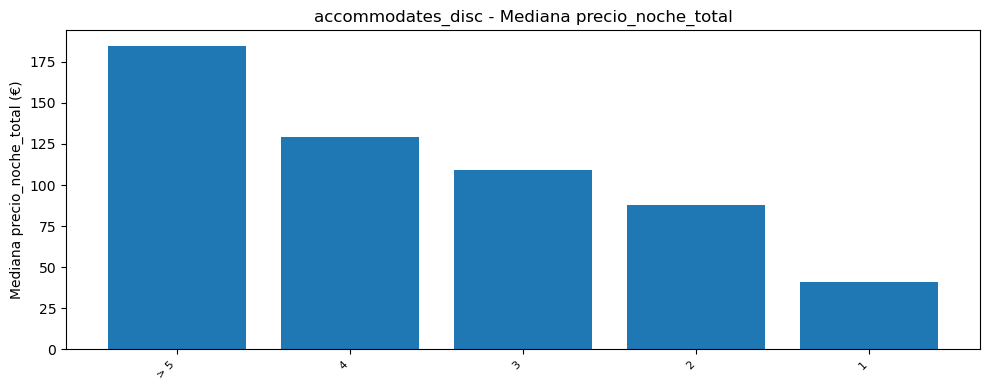

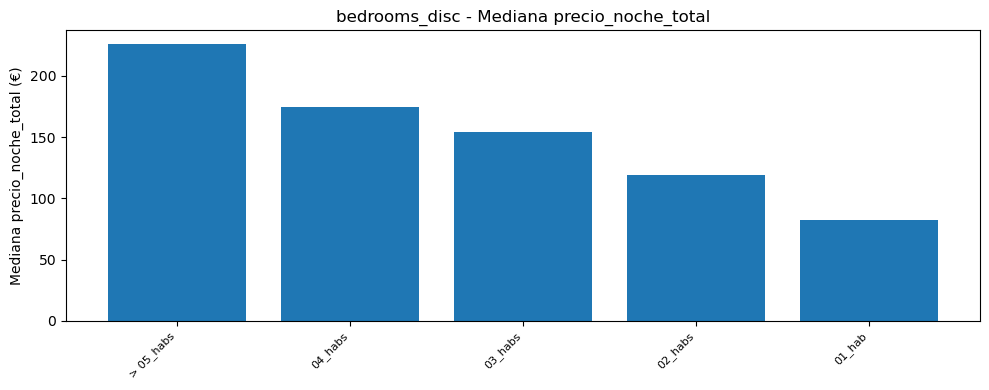

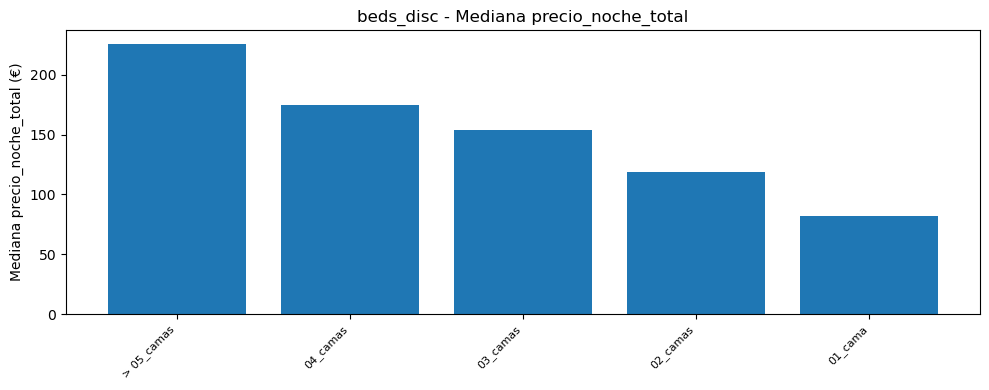

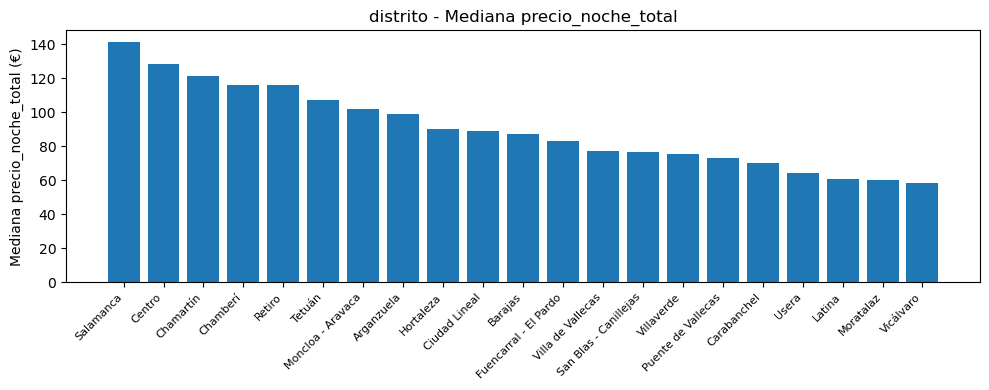

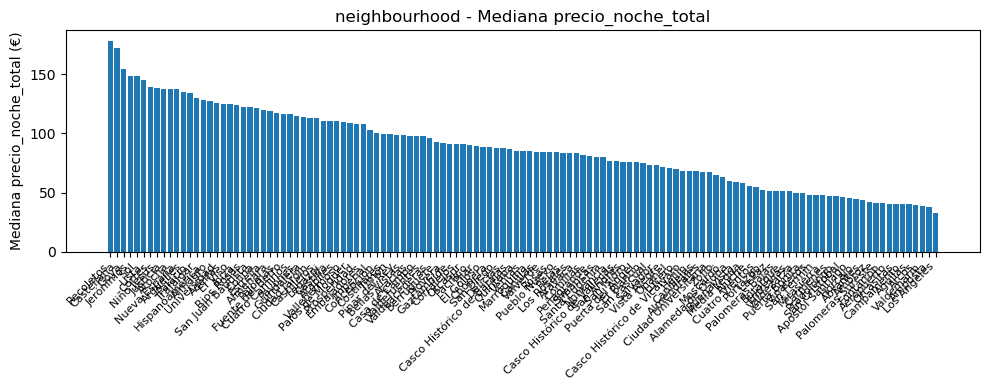

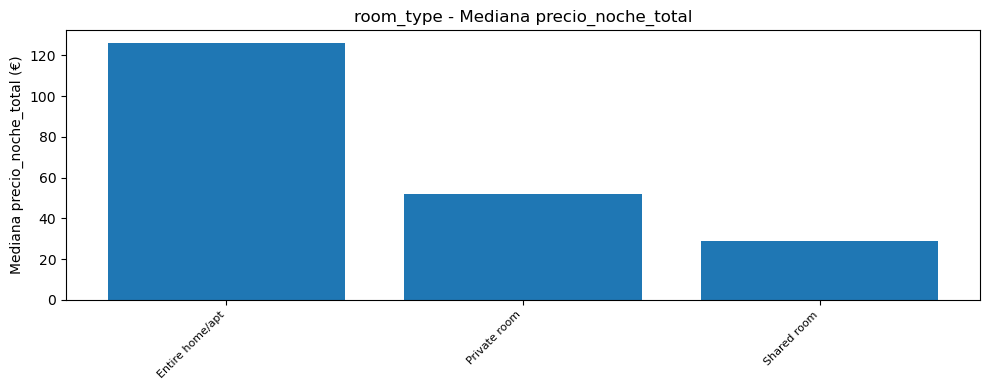

In [369]:
# Filtramos solo la métrica de interés
metrica = 'mediana_precio_noche_total'

# Obtenemos las dimensiones únicas
dimensiones_unicas = minicubo_agg['dimension'].unique()

for dimension in dimensiones_unicas:
    datos = minicubo_agg[minicubo_agg['dimension'] == dimension].sort_values(metrica, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['valor'].astype(str), datos[metrica])
    plt.title(f"{dimension} - Mediana precio_noche_total")
    plt.ylabel("Mediana precio_noche_total (€)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

In [370]:
# Elimina filas de neighbourhood 'Fuentelareina'
df = df[df['neighbourhood'] != 'Fuentelareina']

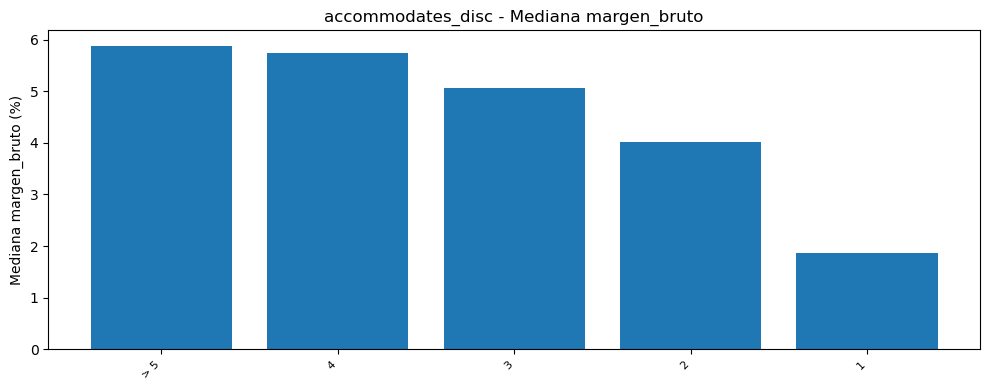

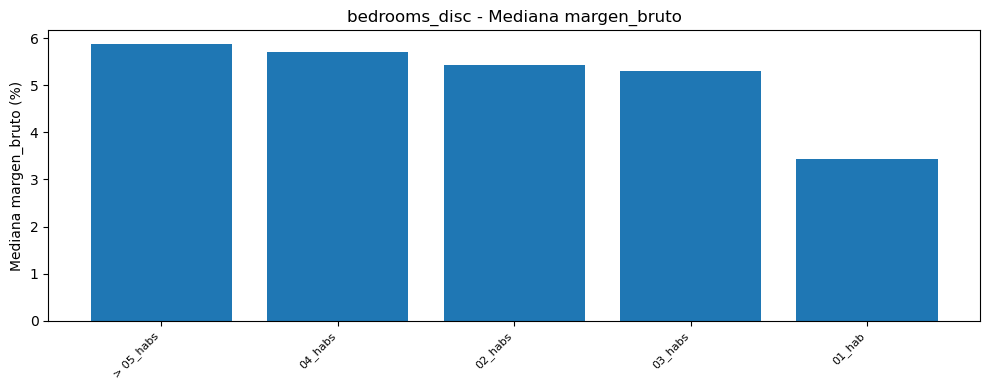

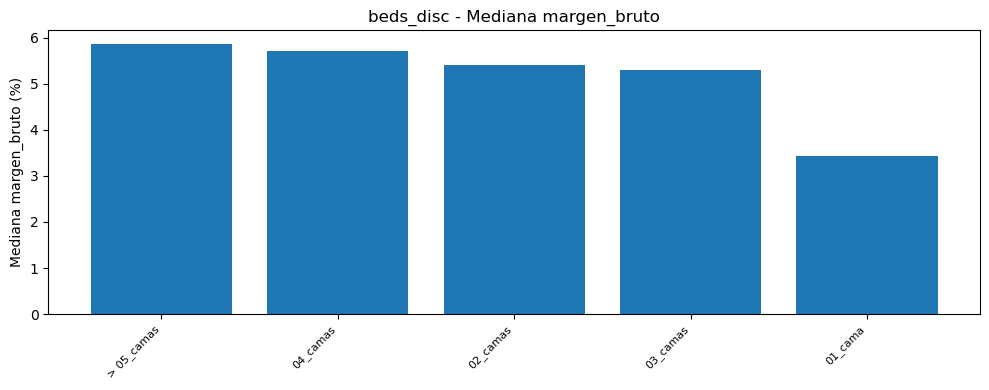

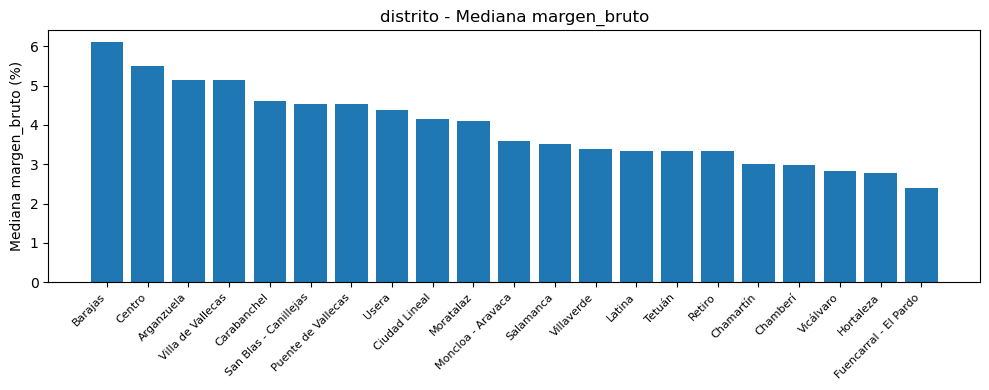

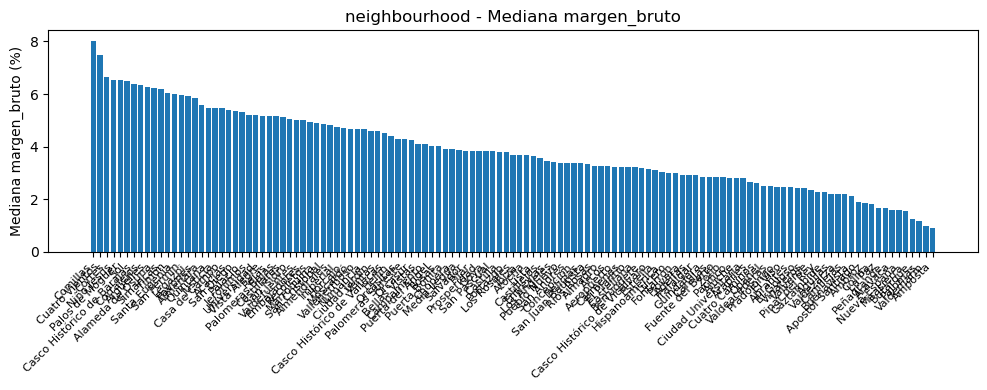

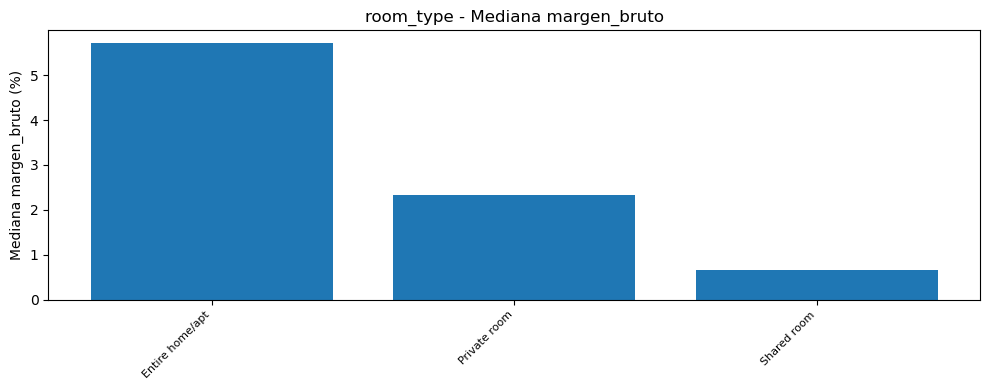

In [371]:
metrica = 'mediana_margen_bruto'
dimensiones_unicas = minicubo_agg['dimension'].unique()

for dimension in dimensiones_unicas:
    datos = minicubo_agg[minicubo_agg['dimension'] == dimension].sort_values(metrica, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['valor'].astype(str), datos[metrica])
    plt.title(f"{dimension} - Mediana margen_bruto")
    plt.ylabel("Mediana margen_bruto (%)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

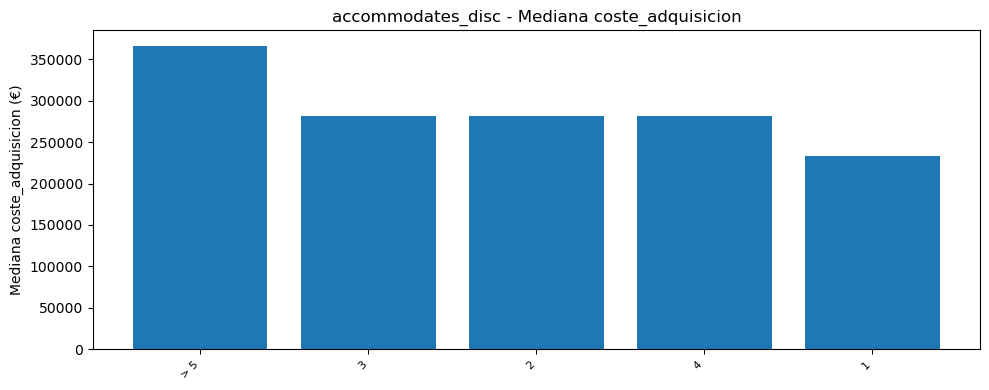

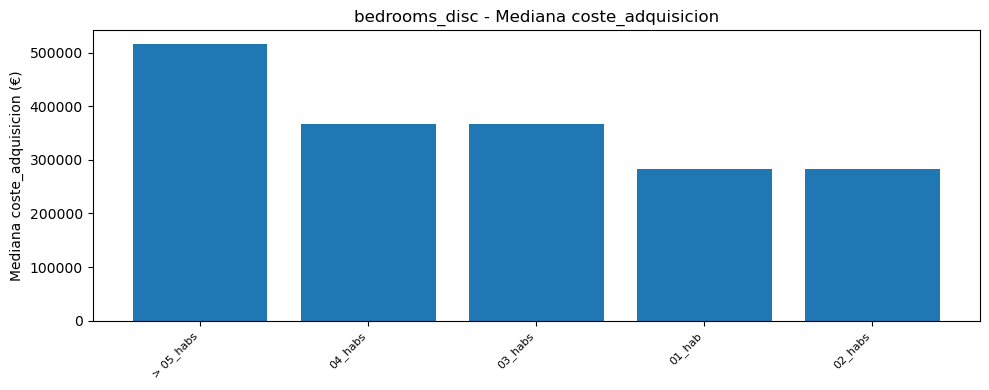

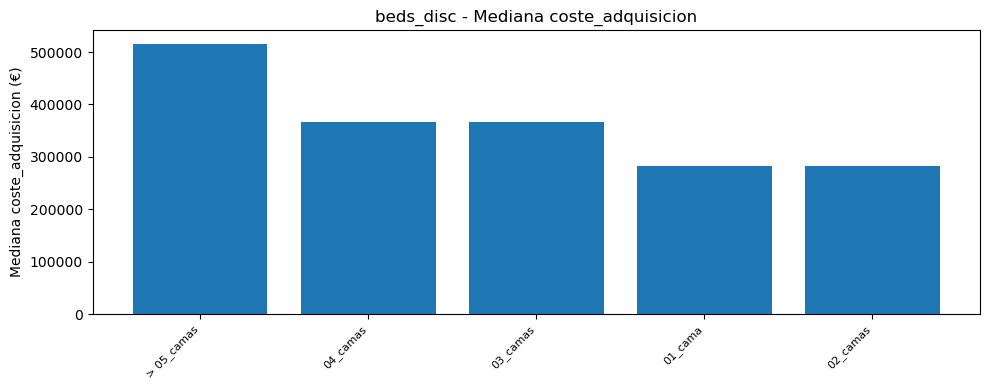

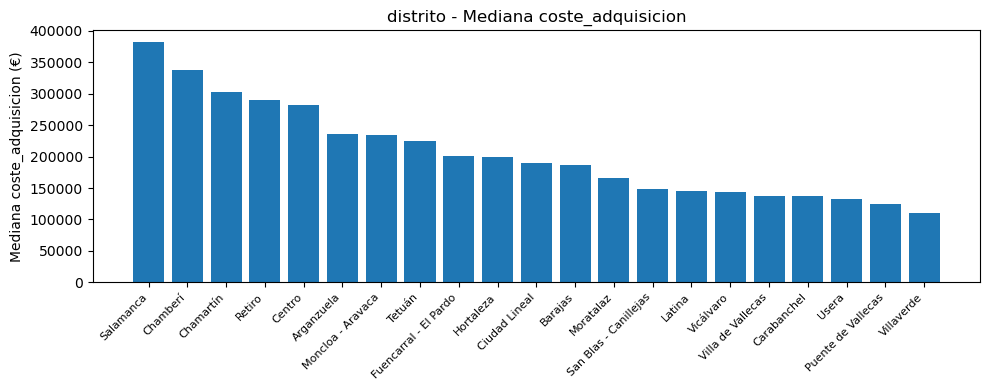

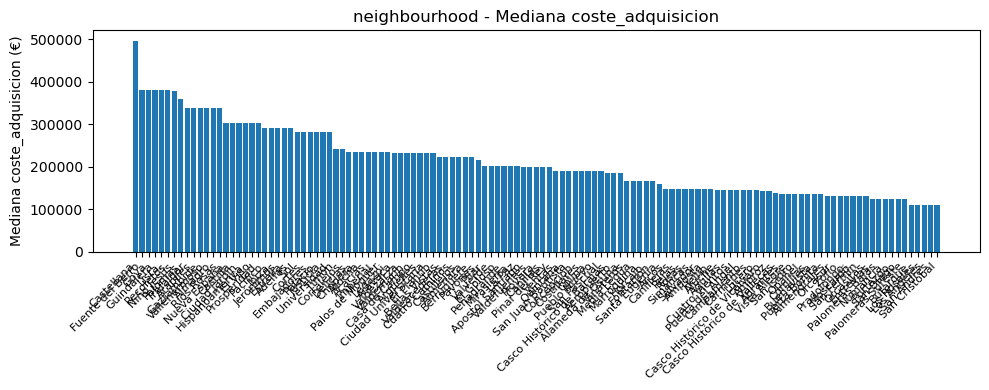

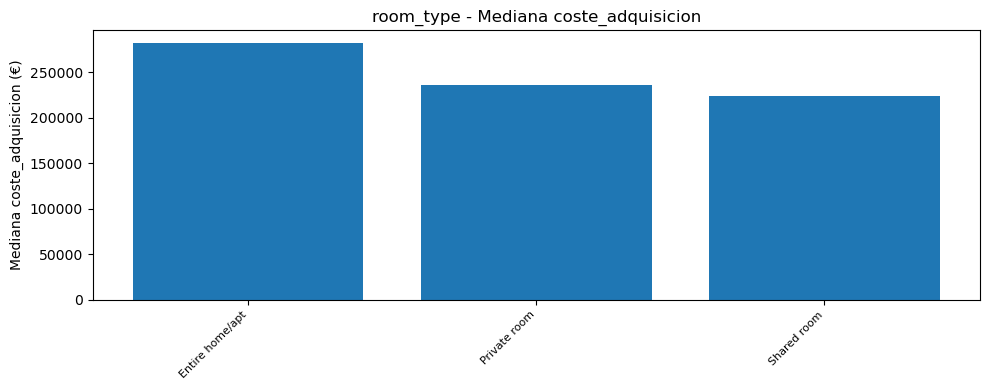

In [372]:
metrica = 'mediana_coste_adquisicion'
dimensiones_unicas = minicubo_agg['dimension'].unique()

for dimension in dimensiones_unicas:
    datos = minicubo_agg[minicubo_agg['dimension'] == dimension].sort_values(metrica, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['valor'].astype(str), datos[metrica])
    plt.title(f"{dimension} - Mediana coste_adquisicion")
    plt.ylabel("Mediana coste_adquisicion (€)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

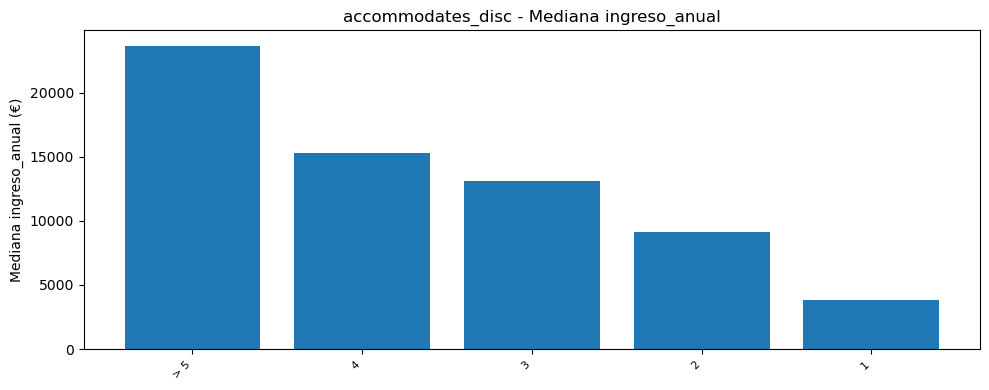

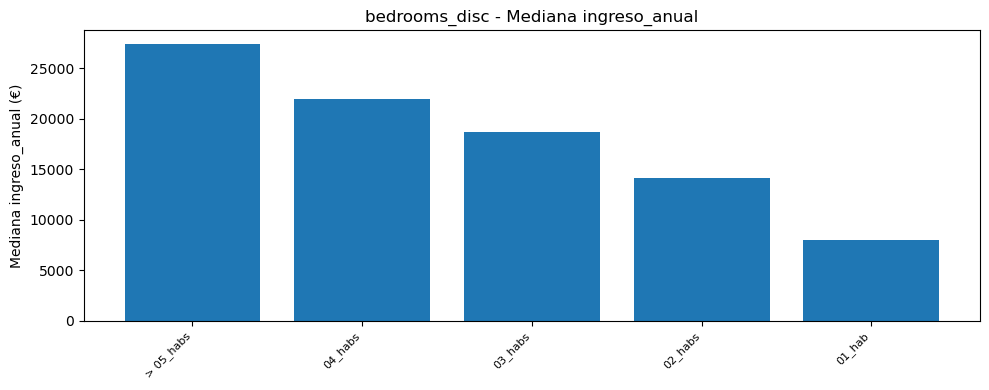

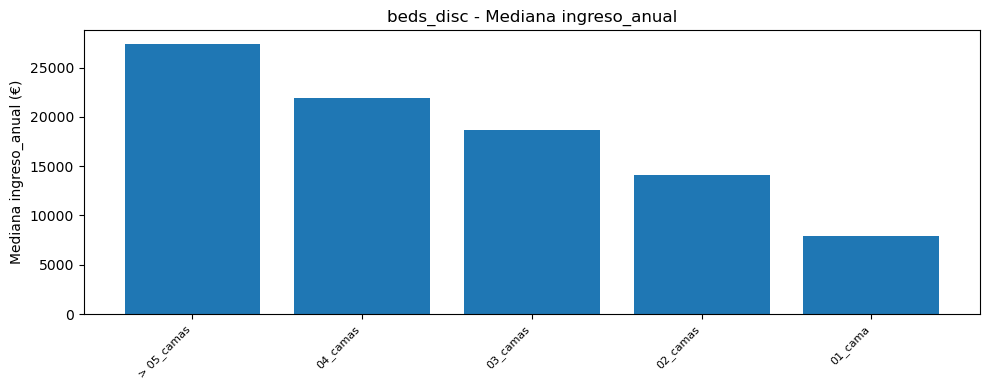

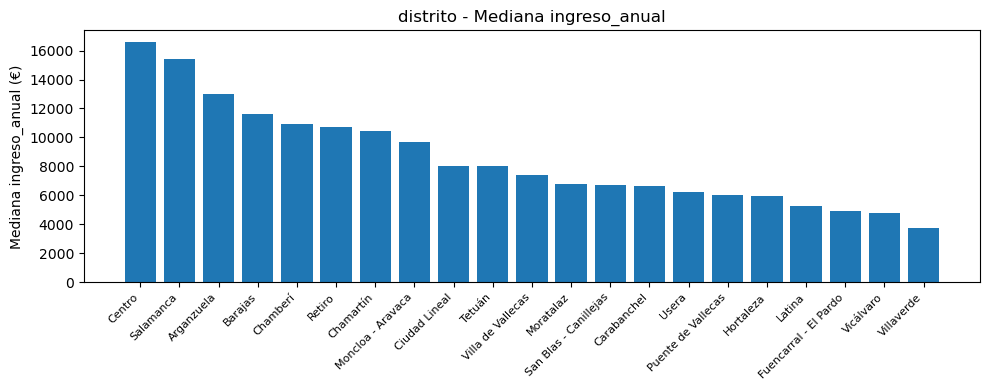

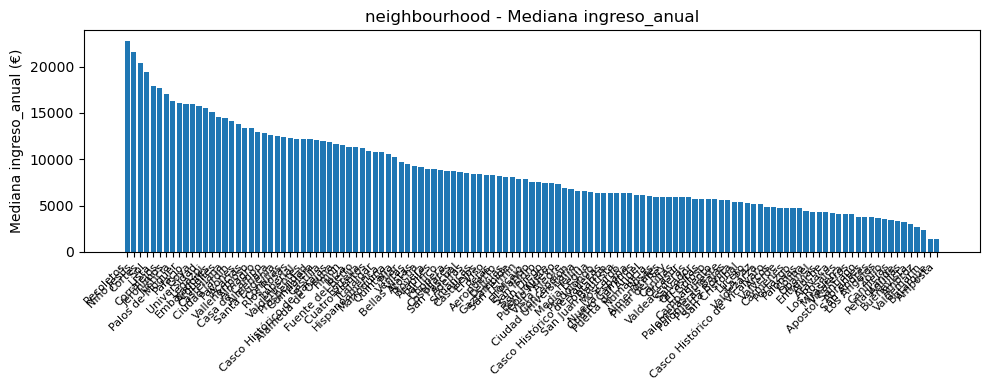

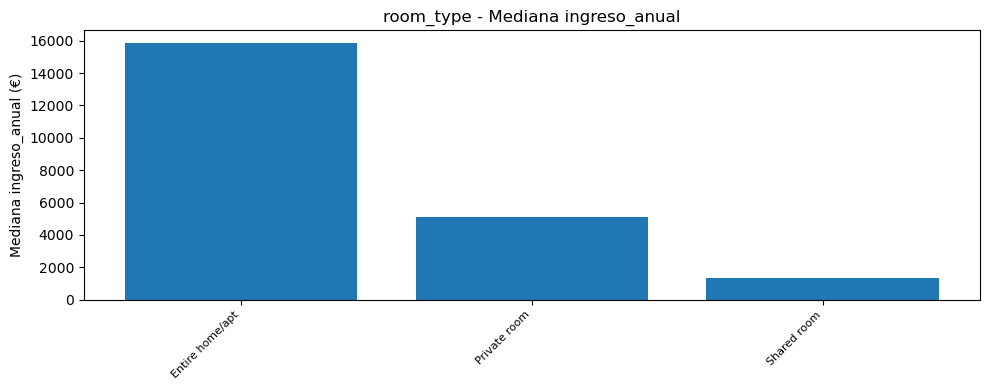

In [373]:
metrica = 'mediana_ingreso_anual'
dimensiones_unicas = minicubo_agg['dimension'].unique()

for dimension in dimensiones_unicas:
    datos = minicubo_agg[minicubo_agg['dimension'] == dimension].sort_values(metrica, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['valor'].astype(str), datos[metrica])
    plt.title(f"{dimension} - Mediana ingreso_anual")
    plt.ylabel("Mediana ingreso_anual (€)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

# Análisis de Insights

- **bedrooms**: de 2 a 3  
- **accommodates**: más de 3  
- **beds**: más de 2  
- **distritos**: Barajas, Centro, Arganzuela, Villa de Vallecas  

> Podemos obtener rentabilidades de hasta un **40%**.

In [374]:
# Filtrado según las condiciones indicadas
filtro = (
    (df['bedrooms'].isin([2, 3])) &
    (df['accommodates'] >= 3) &
    (df['beds'] >= 2) &
    (df['distrito'].isin(['Barajas', 'Centro', 'Arganzuela', 'Villa de Vallecas']))
)

df_filtrado = df[filtro]
df_filtrado

,name,neighbourhood,latitude,longitude,room_type,precio_noche,minimum_nights,availability_365,description,accommodates,...,precio_noche_total,ingreso_anual,m2_estimado,coste_adquisicion,atractivo_turistico,beds_disc,bathrooms_disc,accommodates_disc,bedrooms_disc,margen_bruto
5,Sunny attic duplex flat with terrace next to Sol,Embajadores,40.411500,-3.704490,Entire home/apt,300.0,3,365,"Nestled in the serene heart of Madrid, this re...",6,...,300.0,27000.0,90.0,507870.0,74.117940,> 05_camas,<= 1_toilet,> 5,> 05_habs,5.32
6,Cozy attic with intimate rooftop terrace+ elev...,Embajadores,40.409390,-3.698120,Entire home/apt,166.0,3,365,"Nestled in Madrid's tranquil heart, this apart...",6,...,166.0,20916.0,90.0,507870.0,70.867481,03_camas,<= 1_toilet,> 5,03_habs,4.12
11,Lovely 110m2 home - Best location!,Cortes,40.415200,-3.696680,Entire home/apt,160.0,5,365,"SPACIOUS, 2 BEDROOM HOLIDAY HOME: 2 BATHROOMS,...",5,...,160.0,6400.0,65.0,366795.0,75.788632,02_camas,1 - 2 toilets,> 5,02_habs,1.74
14,Apartament Center Atocha ll,Embajadores,40.413100,-3.700860,Entire home/apt,117.0,5,365,NaN,4,...,117.0,29835.0,65.0,366795.0,75.732170,> 05_camas,1 - 2 toilets,4,> 05_habs,8.13
24,2 bedroom apartament in Chueca-Fuen,Justicia,40.422420,-3.695620,Entire home/apt,84.0,5,365,Comfy and cozzy Two bedrooms apartment in Down...,5,...,84.0,9240.0,65.0,366795.0,72.727835,04_camas,<= 1_toilet,> 5,04_habs,2.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13908,Piso Nuevo Exterior Dos Dormitorios Centro Ciudad,Embajadores,40.410230,-3.698850,Entire home/apt,152.0,1,365,Discover this cozy and modern apartment in a c...,6,...,152.0,1824.0,65.0,366795.0,72.175285,03_camas,<= 1_toilet,> 5,03_habs,0.50
13962,Fuencarral XXIII,Justicia,40.427935,-3.701677,Entire home/apt,455.0,1,365,"This spacious, renovated apartment with modern...",6,...,455.0,2730.0,110.0,620730.0,67.645185,04_camas,1 - 2 toilets,> 5,04_habs,0.44
13969,Piso elegante en Atocha 2 hab. 2 baños,Embajadores,40.410140,-3.697220,Entire home/apt,246.0,2,365,"It has a privileged location, which will make ...",4,...,246.0,1476.0,65.0,366795.0,71.586481,02_camas,1 - 2 toilets,4,02_habs,0.40
13970,Piso Amplio cerca Plaza de España 2 hab 2 baños,Palacio,40.419857,-3.708920,Entire home/apt,253.0,2,365,"It has a privileged location, which will make ...",4,...,253.0,1518.0,65.0,366795.0,76.022011,02_camas,1 - 2 toilets,4,02_habs,0.41


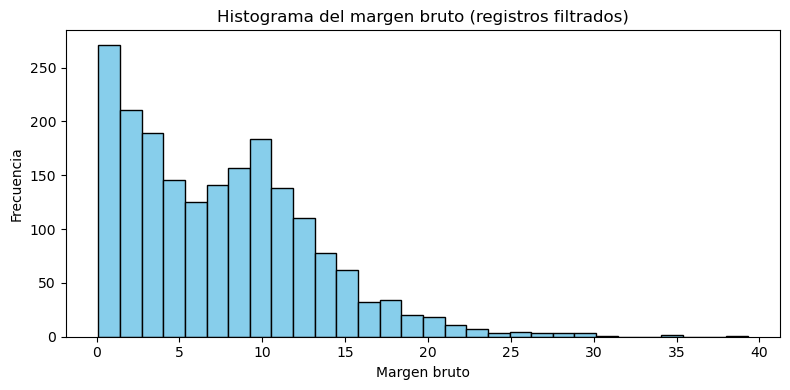

In [375]:
plt.figure(figsize=(8, 4))
plt.hist(df_filtrado['margen_bruto'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histograma del margen bruto (registros filtrados)')
plt.xlabel('Margen bruto')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

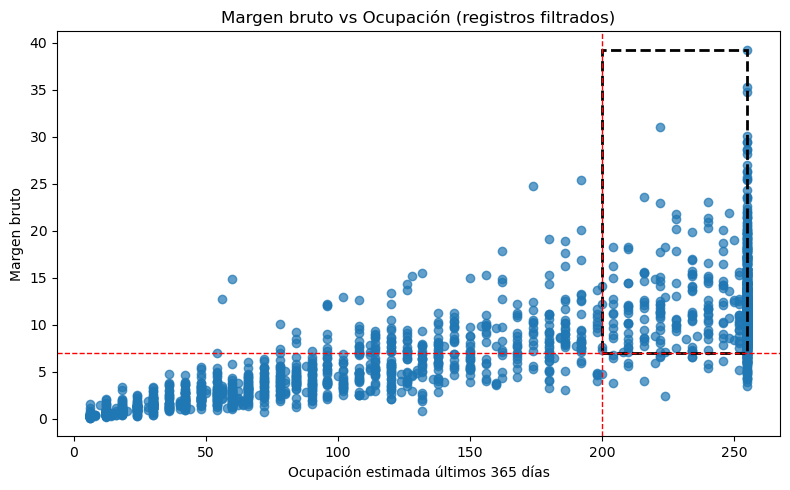

In [376]:
plt.figure(figsize=(8, 5))
plt.scatter(df_filtrado['estimated_occupancy_l365d'], df_filtrado['margen_bruto'], alpha=0.7)
plt.xlabel('Ocupación estimada últimos 365 días')
plt.ylabel('Margen bruto')
plt.title('Margen bruto vs Ocupación (registros filtrados)')

# Dibuja el recuadro de la zona de interés
plt.axhline(7, color='red', linestyle='--', linewidth=1)
plt.axvline(200, color='red', linestyle='--', linewidth=1)
plt.gca().add_patch(
    plt.Rectangle(
        (200, 7),                # esquina inferior izquierda
        df_filtrado['estimated_occupancy_l365d'].max() - 200,  # ancho
        df_filtrado['margen_bruto'].max() - 7,                 # alto
        fill=False, edgecolor='black', linewidth=2, linestyle='--'
    )
)

plt.tight_layout()
plt.show()

# Análisis de Ocupación

#### Insights análisis ocupación (Inmuebles con mayor ocupación):

- 4 o más habitaciones 
- Con 5 o más personas   
- Especial interes en Barajas, es posible comprar inmuebles con ocupación superior a 200 días y rentabilidad superior al 10% por menos de 200.000

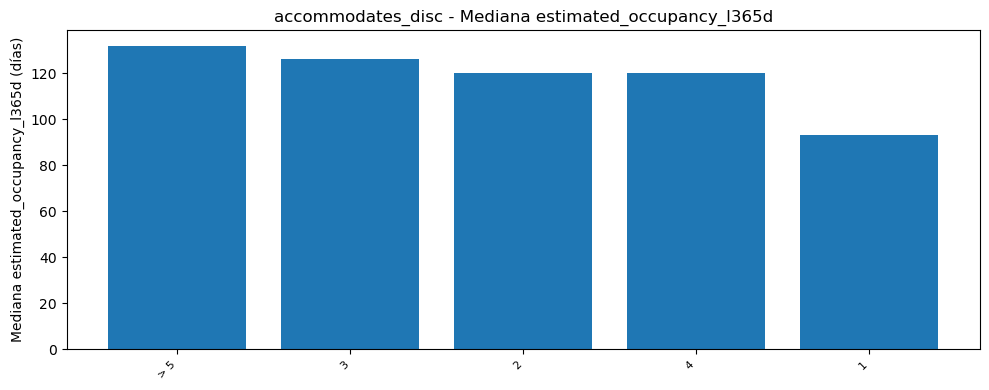

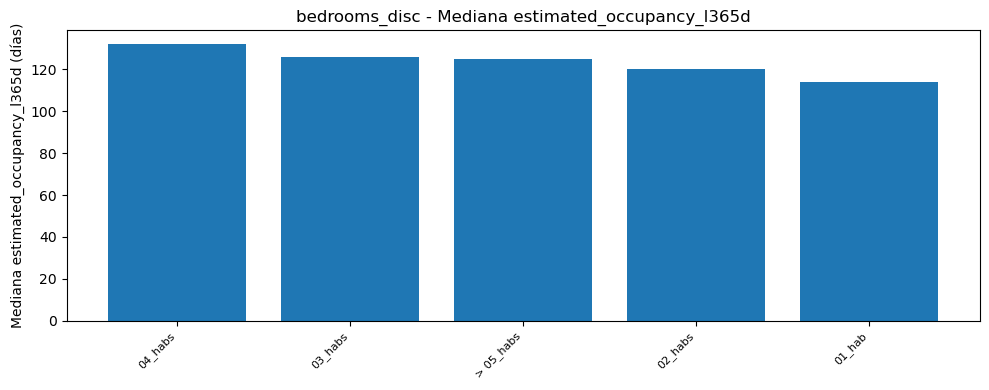

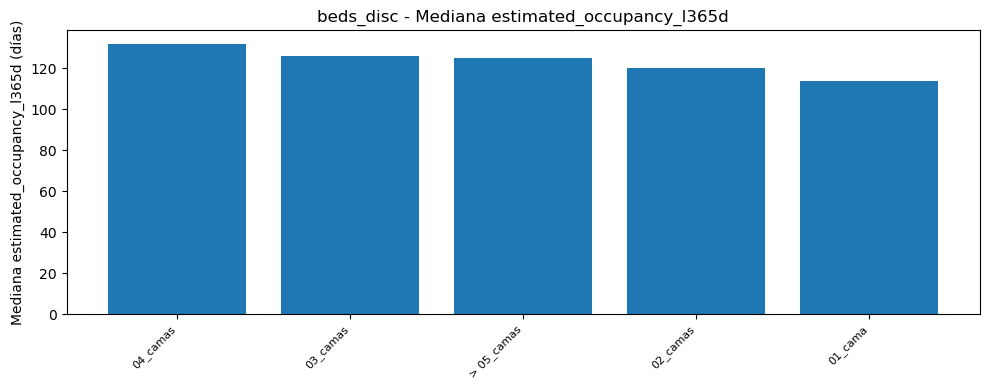

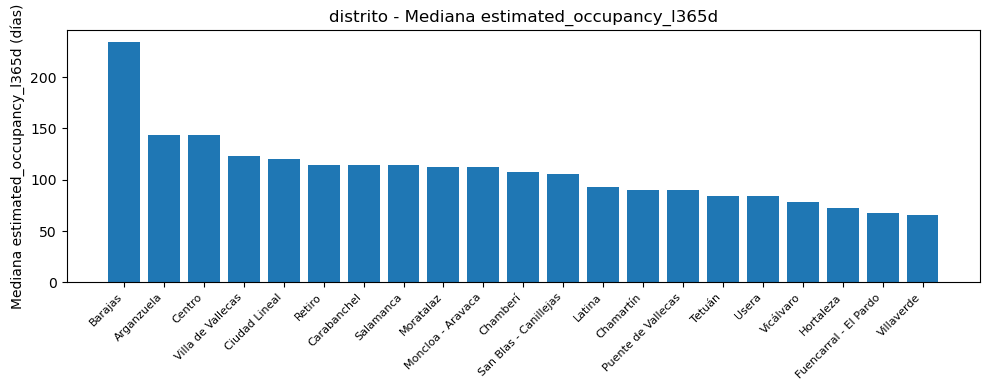

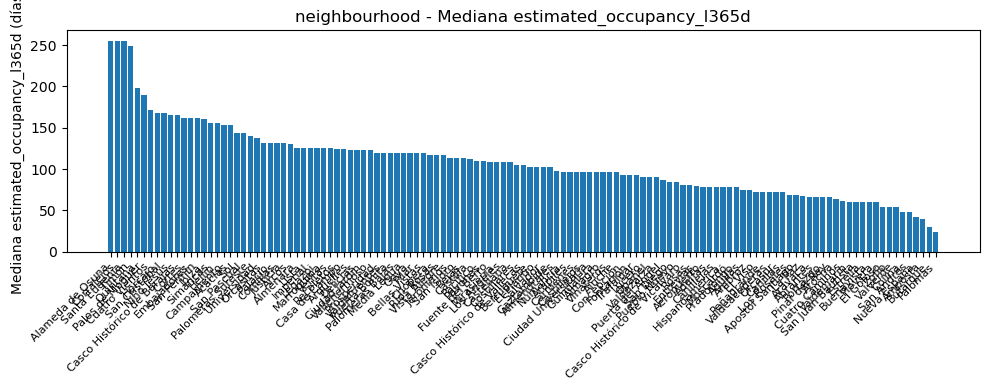

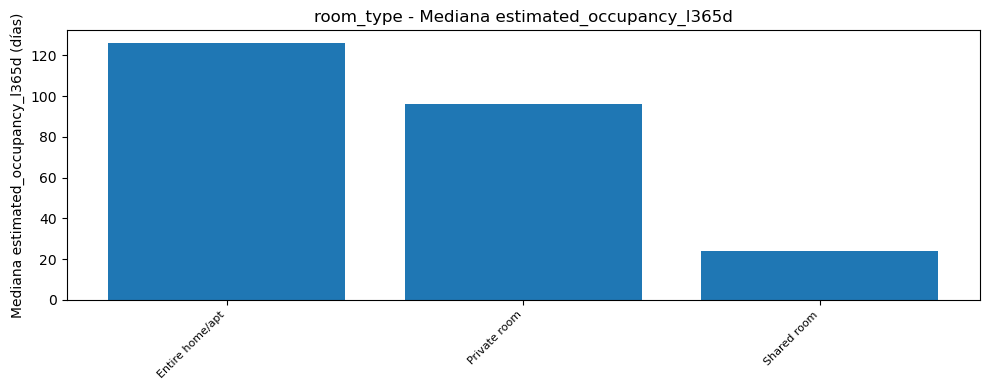

In [377]:
metrica = 'mediana_ocupacion'
dimensiones_unicas = minicubo_agg['dimension'].unique()

for dimension in dimensiones_unicas:
    datos = minicubo_agg[minicubo_agg['dimension'] == dimension].sort_values(metrica, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(datos['valor'].astype(str), datos[metrica])
    plt.title(f"{dimension} - Mediana estimated_occupancy_l365d")
    plt.ylabel("Mediana estimated_occupancy_l365d (días)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()

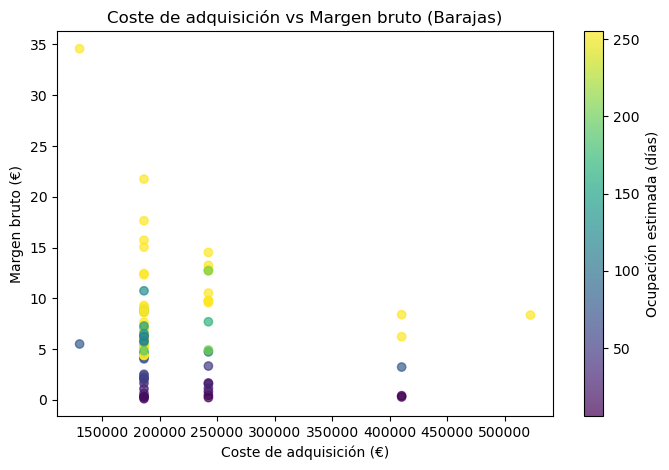

In [378]:
# Crear un data frame con los registros de barajas
df_barajas = df[df['distrito'] == 'Barajas']

# Crear un scatter plot de coste adquisición vs margen bruto y la ocupación estimada como puntos de colores
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df_barajas['coste_adquisicion'], df_barajas['margen_bruto'], c=df_barajas['estimated_occupancy_l365d'], cmap='viridis', alpha=0.7)
plt.xlabel('Coste de adquisición (€)')
plt.ylabel('Margen bruto (€)')
plt.title('Coste de adquisición vs Margen bruto (Barajas)')
cbar = plt.colorbar(scatter)
cbar.set_label('Ocupación estimada (días)')
plt.show()

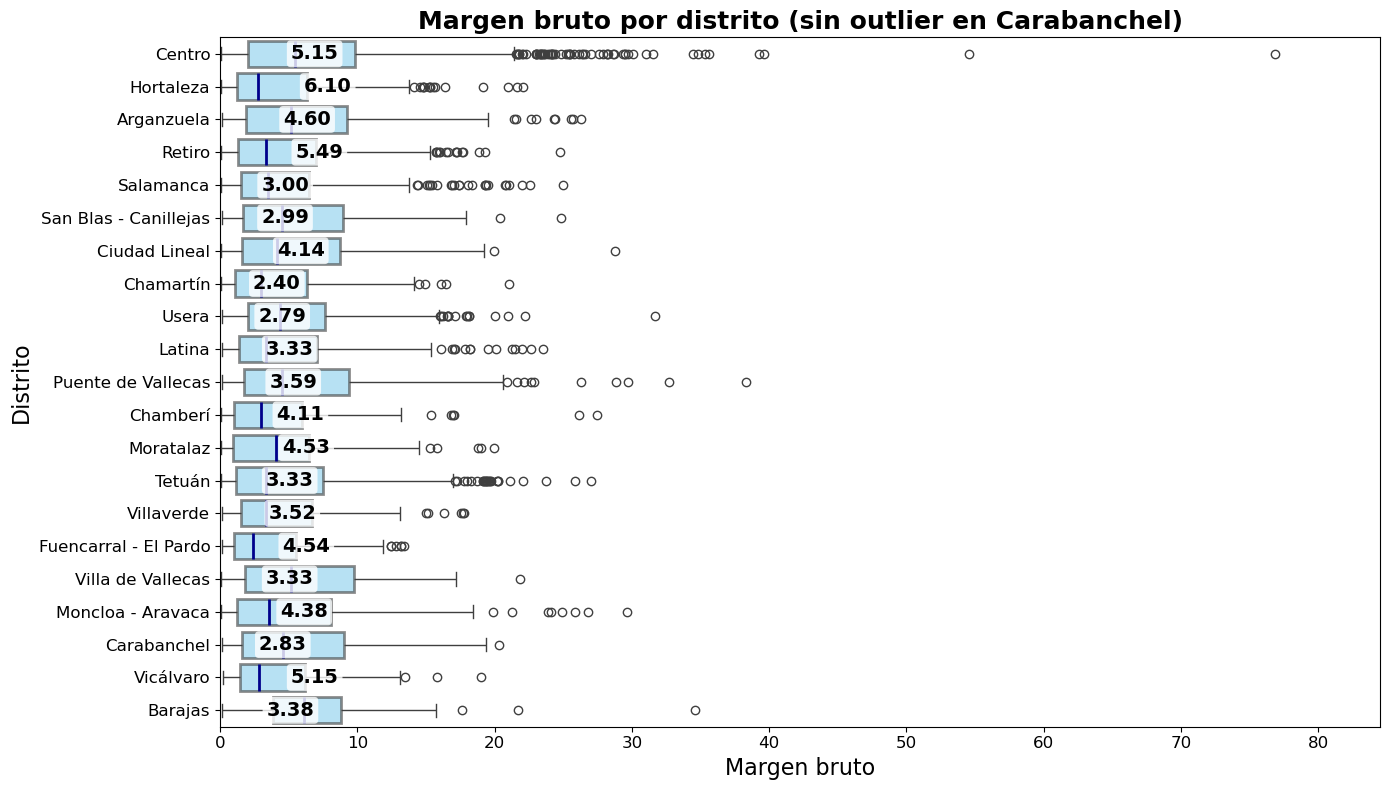

In [379]:
# Copia el DataFrame original
df_filtrado = df.copy()

# Calcula el percentil 99 para margen_bruto en Carabanchel
umbral = df_filtrado[df_filtrado['distrito'] == 'Carabanchel']['margen_bruto'].quantile(0.99)

# Elimina los outliers solo en Carabanchel
df_filtrado = df_filtrado[~((df_filtrado['distrito'] == 'Carabanchel') & (df_filtrado['margen_bruto'] > umbral))]

plt.figure(figsize=(14, 8))
box = sns.boxplot(
    x='margen_bruto', 
    y='distrito', 
    data=df_filtrado, 
    orient='h',
    boxprops=dict(facecolor='skyblue', alpha=0.6, linewidth=2),
    medianprops=dict(color='darkblue', linewidth=2)
)
medianas = df_filtrado.groupby('distrito')['margen_bruto'].median()
for i, distrito in enumerate(medianas.index):
    plt.text(
        medianas[distrito], i, f'{medianas[distrito]:.2f}',
        va='center', ha='left', fontsize=14, fontweight='bold',
        color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2')
    )
plt.xlim(0, df_filtrado['margen_bruto'].max() * 1.1)
plt.xlabel('Margen bruto', fontsize=16)
plt.ylabel('Distrito', fontsize=16)
plt.title('Margen bruto por distrito (sin outlier en Carabanchel)', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Nivel 1: ¿Qué comprar en los siguientes distritos?

Comprar piso completo, menos en Barajas, donde también se recomienda Private room y Shared Room.

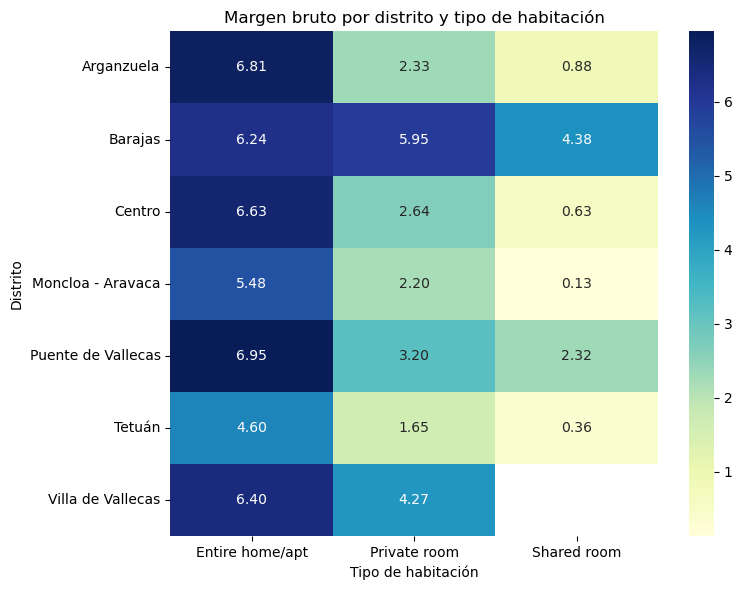

In [380]:
# Crea un df con los registros Centro, Arganzuela, Moncloa - Aravaca y Puente de Vallecas
df_seleccionados = df_filtrado[df_filtrado['distrito'].isin(['Centro', 'Arganzuela', 'Moncloa - Aravaca', 'Tetuán', 'Puente de Vallecas', 'Barajas', 'Villa de Vallecas'])]

# Sobre ese df crea un mapa de calor con el margen bruto
pivot = df_seleccionados.pivot_table(index='distrito', columns='room_type', values='margen_bruto', aggfunc='median')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Margen bruto por distrito y tipo de habitación')
plt.xlabel('Tipo de habitación')
plt.ylabel('Distrito')
plt.tight_layout()
plt.show()

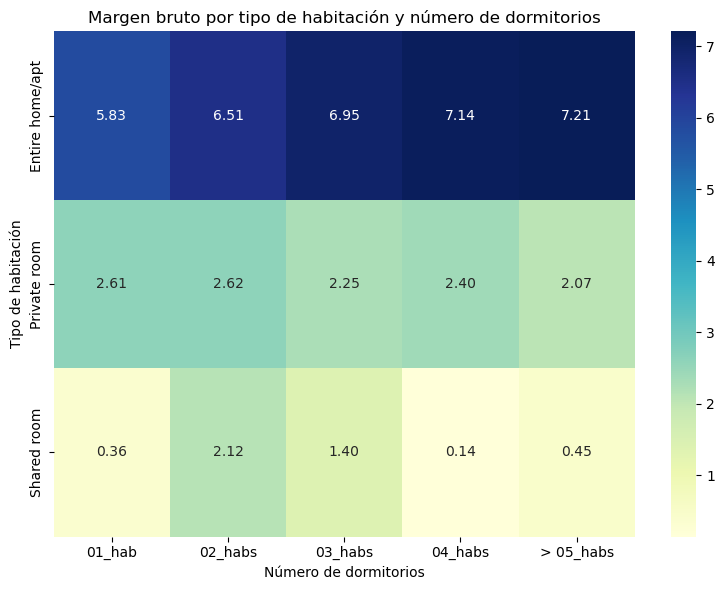

In [381]:
# crea un heatmap con el margen_bruto por room_type y bedrooms_disc
pivot = df_seleccionados.pivot_table(index='room_type', columns='bedrooms_disc', values='margen_bruto', aggfunc='median')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Margen bruto por tipo de habitación y número de dormitorios')
plt.xlabel('Número de dormitorios')
plt.ylabel('Tipo de habitación')
plt.tight_layout()
plt.show()

# Nivel 2: ¿Qué comprar en el resto de distritos?

- 5+ habitaciones en Usera, Moratalaz y Puente de Vallecas
- 3 o +5 habitaciones para Barajas
- 3 habitaciones en Carabanchel
- 2 habitaciones en San Blas
- Investigar Barajas y Usera

En todos ellos para alquilar por piso completo y que se puedan acomodar 4 o más personas.



In [382]:
# Sobre df filtra solo los que son Entire/room y que no son de distritos Villa de Vallecas, Barajas y Centro
filtro = (
    (df['room_type'] == 'Entire home/apt') &
    (~df['distrito'].isin(['Villa de Vallecas', 'Barajas', 'Centro']))
)
df_filtrado = df[filtro]

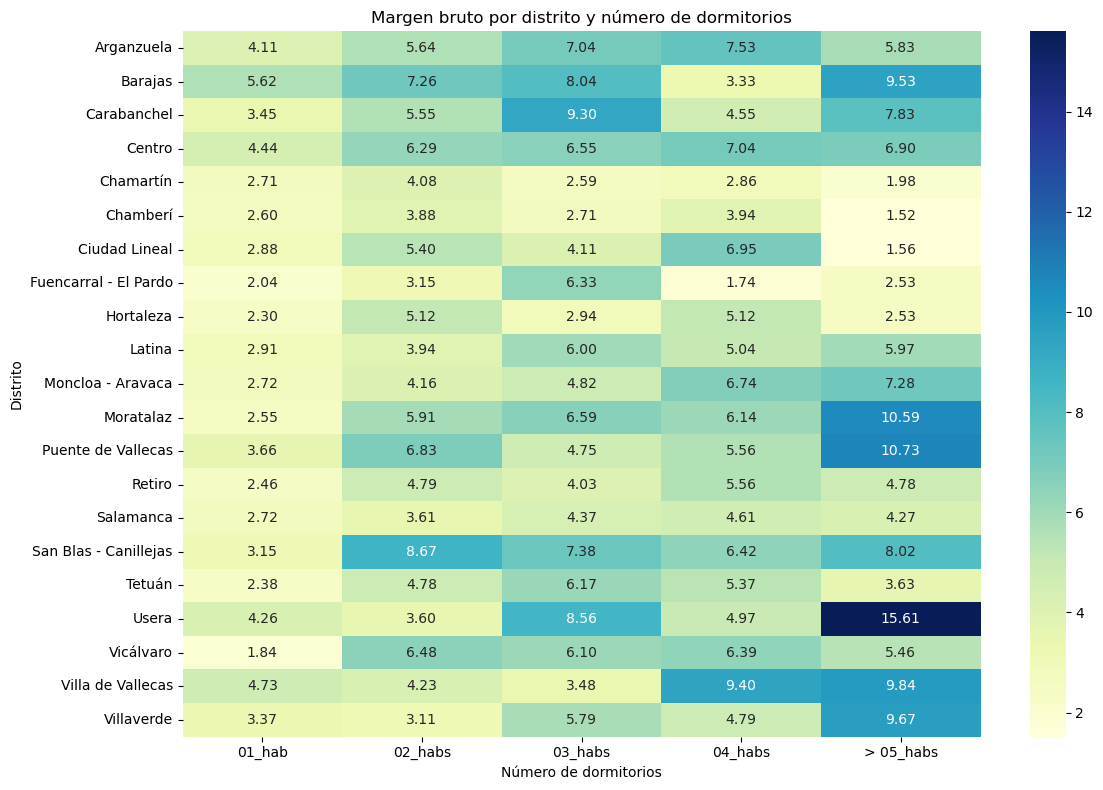

In [383]:
# Lista completa de distritos presentes en el DataFrame original
todos_distritos = sorted(df['distrito'].unique())

# Creamos el pivot asegurando que todos los distritos estén como índice
pivot = df.pivot_table(
    index='distrito',
    columns='bedrooms_disc',
    values='margen_bruto',
    aggfunc='median'
).reindex(todos_distritos)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Margen bruto por distrito y número de dormitorios')
plt.xlabel('Número de dormitorios')
plt.ylabel('Distrito')
plt.tight_layout()
plt.show()

## Nivel 3: Análisis por barrios

In [384]:
# Agrupa por distrito, neighbourhood, bedrooms_disc, accommodates_disc y calcula la mediana de margen_bruto y estimated_occupancy_l365d
agrupado = df.groupby(['distrito', 'neighbourhood', 'bedrooms_disc', 'accommodates_disc']).agg(
    mediana_margen_bruto=('margen_bruto', 'median'),
    mediana_estimated_occupancy_l365d=('estimated_occupancy_l365d', 'median')
).reset_index()

# ordena por margen_bruto descendente y muestra los 20 primeros
agrupado_ordenado = agrupado.sort_values(by='mediana_margen_bruto', ascending=False).head(20)
agrupado_ordenado

,distrito,neighbourhood,bedrooms_disc,accommodates_disc,mediana_margen_bruto,mediana_estimated_occupancy_l365d
1126,San Blas - Canillejas,Simancas,02_habs,2,24.850,246.0
683,Latina,Aluche,01_hab,4,23.520,255.0
1256,Usera,Orcasur,> 05_habs,> 5,20.970,255.0
862,Puente de Vallecas,Numancia,> 05_habs,> 5,20.325,208.5
688,Latina,Aluche,03_habs,> 5,20.140,255.0
835,Moratalaz,Vinateros,02_habs,4,19.000,228.0
818,Moratalaz,Marroquina,01_hab,4,18.760,168.0
531,Ciudad Lineal,San Juan Bautista,01_hab,3,18.280,255.0
690,Latina,Aluche,04_habs,> 5,18.190,255.0
1206,Tetuán,Cuatro Caminos,> 05_habs,> 5,17.760,255.0


In [390]:
import folium
from folium.plugins import HeatMap

df_mapa = df[['latitude', 'longitude', 'margen_bruto']].dropna()
madrid_coords = [40.4168, -3.7038]
m = folium.Map(location=madrid_coords, zoom_start=11)

head_data = [[row['latitude'], row['longitude'], row['margen_bruto']] for index, row in df_mapa.iterrows()]
HeatMap(head_data, radius=25, blur=15, max_zoom=1).add_to(m)

from IPython.display import display
display(m)

# Muestra el mapa
m.save('mapa_rentabilidad_distritos.html')